Below is my implementation of getting the band diamgrams utilizng the MPB library of Meep

In [89]:
# Importing Libraries: 

import meep as mp
import matplotlib.pyplot as plt
import numpy as np 
from IPython.display import Video 
from meep import mpb
from scipy.optimize import minimize

%matplotlib inline 

In [90]:
def banddiagram_wmpb(width: float, length: float, xlength: float, ylength: float, show_geometry: bool, band_diagram: str):
    # width - width of our beam in nanometers
    # length - length of our beam in nanometers
    # ylength- length of ellipsoid axis in y direction of holes patterned into the beam in nanometers
    # xlength - length of ellipsoid axis in x direction 
    # Show_geometry - boolean value for if you want to show the geometry or not
    # band_diagram - 'all' string value to show all band gaps, 'max' to show only the largest band gap

    # It is to note that Meep utlizes normalized units, so I set the length scale to the length of our unit cell
    
    c = 3e8 # Speed of light for conversion later

    # Parameters for the computational cell: 
    pml_padding = length  
    padding_to_pml = 4*length
    sx = 1       # We will scale the dimensions of everything else by the length (for example we scaled the paddings above by the length)
    sy = 2*(pml_padding + padding_to_pml + width)/length  
    res = 64     # I had set the resolution to a power of two, I dont know if that will aid in the computational speed but Meep mentioned somewhere in the documentation to do this

    cell = mp.Vector3(sx,sy)
    lattice = mp.Lattice(mp.Vector3(1,1))

    # For the silicon we want to use and our approximate target wavelength is below: 
    eps_silicon = 12
    thickness = 220
    wavelength = 1540 

    # Defining our waveguide given the parameters, meep assumes periodic structure: 
    beam = mp.Block(size = (1, width/length, thickness/length), material = mp.Medium(epsilon = eps_silicon) )
    holes = mp.Ellipsoid(size = mp.Vector3(xlength, ylength, thickness)/length, e1 = mp.Vector3(1,0,0), e2 = mp.Vector3(0,1,0), e3 = mp.Vector3(0,0,1),
                          material = mp.Medium(epsilon = 1))

    geometry = [beam,holes]

    if show_geometry == 1: 
        # Other things for simulation: It is to note that say we want to run for a certian number of periods, then we would divide our time by the frequency below
        fcenter = length/wavelength           # In meep units, the frequency is specified by 1/lambda according to https://meep.readthedocs.io/en/latest/Introduction/#units-in-meep
        df = .5*fcenter

        sym = mp.Mirror(direction=mp.Y, phase=-1)
        # Broad source to excite modes
        source = mp.Source(mp.GaussianSource(fcenter, fwidth = df), mp.Hz, mp.Vector3(0, 0))
        pml_layers = [mp.PML(pml_padding/length, direction =mp.Y)]

        simulation = mp.Simulation(
            cell_size = cell, 
            boundary_layers = pml_layers, 
            geometry = geometry, 
            sources = [source], 
            resolution = res, 
            symmetries=[sym]
        )

        f = plt.figure(dpi=200)
        simulation.plot2D(ax = f.gca())
        f.gca().xaxis.set_visible(False)
        f.suptitle('Geometry of Simulation')
        plt.show()

    # It was more or less the same to the prior implementation of this code, now we will utlize MPB to get the band diagrams: 
    num_bands = 2
    k_points = [mp.Vector3(0), mp.Vector3(.5)]       # Two dimensional simulation but only getting the x component of the wave vectors
    k_points = mp.interpolate(30, k_points)         # Interpolation to get more k vectors for our simulation, set to another power of two
    
    # mpb implementation of the mode solver: 
    ms = mpb.ModeSolver(
        num_bands = num_bands, 
        k_points= k_points, 
        geometry= geometry, 
        geometry_lattice= lattice, 
        resolution= res 
    )

    # We will split the modes up into TE and TM modes: 
    ms.run_te()
    te = ms.all_freqs       # The column index represents the frequencies for the index+1 band
    #print(f' \n The gap list is{ms.gap_list} \n' )
    te_gaps = ms.gap_list

    ms.run_tm()
    tm = ms.all_freqs
    tm_gaps = ms.gap_list

    convfactor = (c/(length*1e3))

    plot_k = np.array(k_points)
    plot_te_freqs = np.array(te)*convfactor
    plot_tm_freqs = (np.array(tm))*convfactor

    #legends = [f'Mode {i+1}' for i in range(num_bands)] Legend is useless when we know modes go up increasing frequency 

    fig = plt.figure(num = 1,dpi = 200, figsize = (10,10))
    ax1 = plt.subplot(2,1,1)
    ax1.plot(plot_k[:,0].T, plot_te_freqs)

    # Plotting the band gaps: 
    max_te = 0
    max_te_percent = 0 
    half_band_te = 0 
    for gap in te_gaps: 
        if gap[0]>1: 
            [max_te, max_te_percent] = [max(max_te, (gap[2] - gap[1])*convfactor), max(max_te_percent, gap[0])]
            half_band_te = ((gap[2] + gap[1])/2)*convfactor
            if band_diagram == 'all':
                ax1.fill_between(plot_k[:,0], gap[1]*convfactor, gap[2]*convfactor, color = 'blue', alpha = .2)
 
    if band_diagram == 'max':
        indexed = te_gaps[:][0].index(max_te_percent)
        ax1.fill_between(plot_k[:,0], te_gaps[indexed][1]*convfactor, te_gaps[indexed][2]*convfactor, color = 'blue', alpha =.2)

    print(f'The mid-point for the TE mode is at {half_band_te} (dashed black line)')
    ax1.axhline(y = half_band_te, color='k', linestyle='--')

    print(f'The largest bandgap is {max_te} THz thick for TE modes')
    ax1.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')
    #ax1.set_ylabel('$\omega$  $[\\frac{2\pi c}{a}]$')
    ax1.set_ylabel('f [THz]')
    ax1.set_title('Band Diagram for TE Modes')
    ax1.set_xlim([0,.5])
    #ax1.legend(legends)
    
    ax2 = plt.subplot(2,1,2)
    ax2.plot(plot_k[:,0].T, plot_tm_freqs)
    

    # Plotting the band gaps: 
    max_tm = 0
    max_tm_percent = 0 
    half_band_tm = 0
    for gap in tm_gaps: 
        if gap[0]>1: 
            [max_tm, max_tm_percent] = [max(max_tm, (gap[2] - gap[1])*convfactor), max(max_tm_percent, gap[0])]
            half_band_tm = ((gap[2] + gap[1])/2)*convfactor
            if band_diagram == 'all':
                ax2.fill_between(plot_k[:,0], gap[1]*convfactor, gap[2]*convfactor, color = 'red', alpha = .2)
    print(f'The mid-point for the TM mode is at {half_band_tm} (dashed black line)')
    ax2.axhline(y = half_band_tm, color='k', linestyle='--')
    if band_diagram == 'max':
        indexed = tm_gaps[:][0].index(max_tm_percent)
        ax2.fill_between(plot_k[:,0], tm_gaps[indexed][1]*convfactor, tm_gaps[indexed][2]*convfactor, color = 'red', alpha =.2)

    


    print(f'The largest bandgap is {max_tm} THz thick for TM modes' )
    ax2.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')
    #ax2.set_ylabel('$\omega$  $[\\frac{2\pi c}{a}]$')
    ax2.set_ylabel('f [THz]')
    ax2.set_title('Band Diagram for TM Modes')
    ax2.set_xlim([0,.5])
    #ax2.legend(legends)

    plt.tight_layout()
    plt.show()

    

<>:115: SyntaxWarning: invalid escape sequence '\p'
<>:146: SyntaxWarning: invalid escape sequence '\p'
<>:115: SyntaxWarning: invalid escape sequence '\p'
<>:146: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1744378/3406316364.py:115: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')
/tmp/ipykernel_1744378/3406316364.py:146: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')


     block, center = (0,0,0)
          size (1,1.66667,0.733333)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     ellipsoid, center = (0,0,0)
          size (0.5,1.16667,0.733333)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)


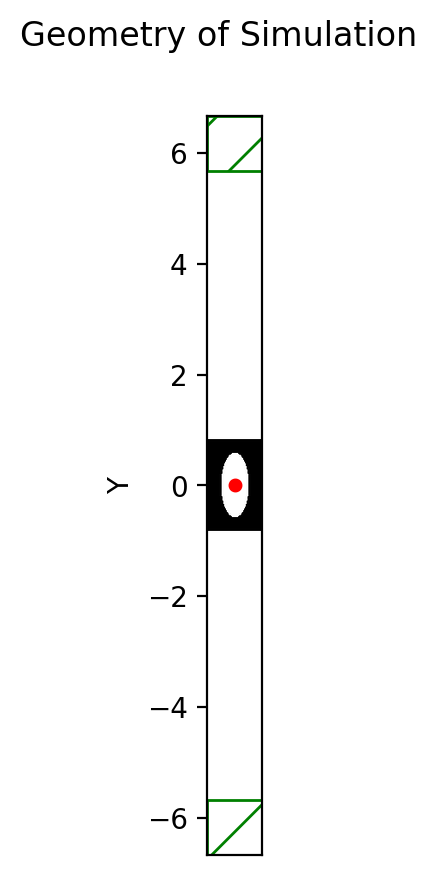

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.66667,0.733333)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.5,1.16667,0.733333)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometric object tree has depth 4 and 24 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0

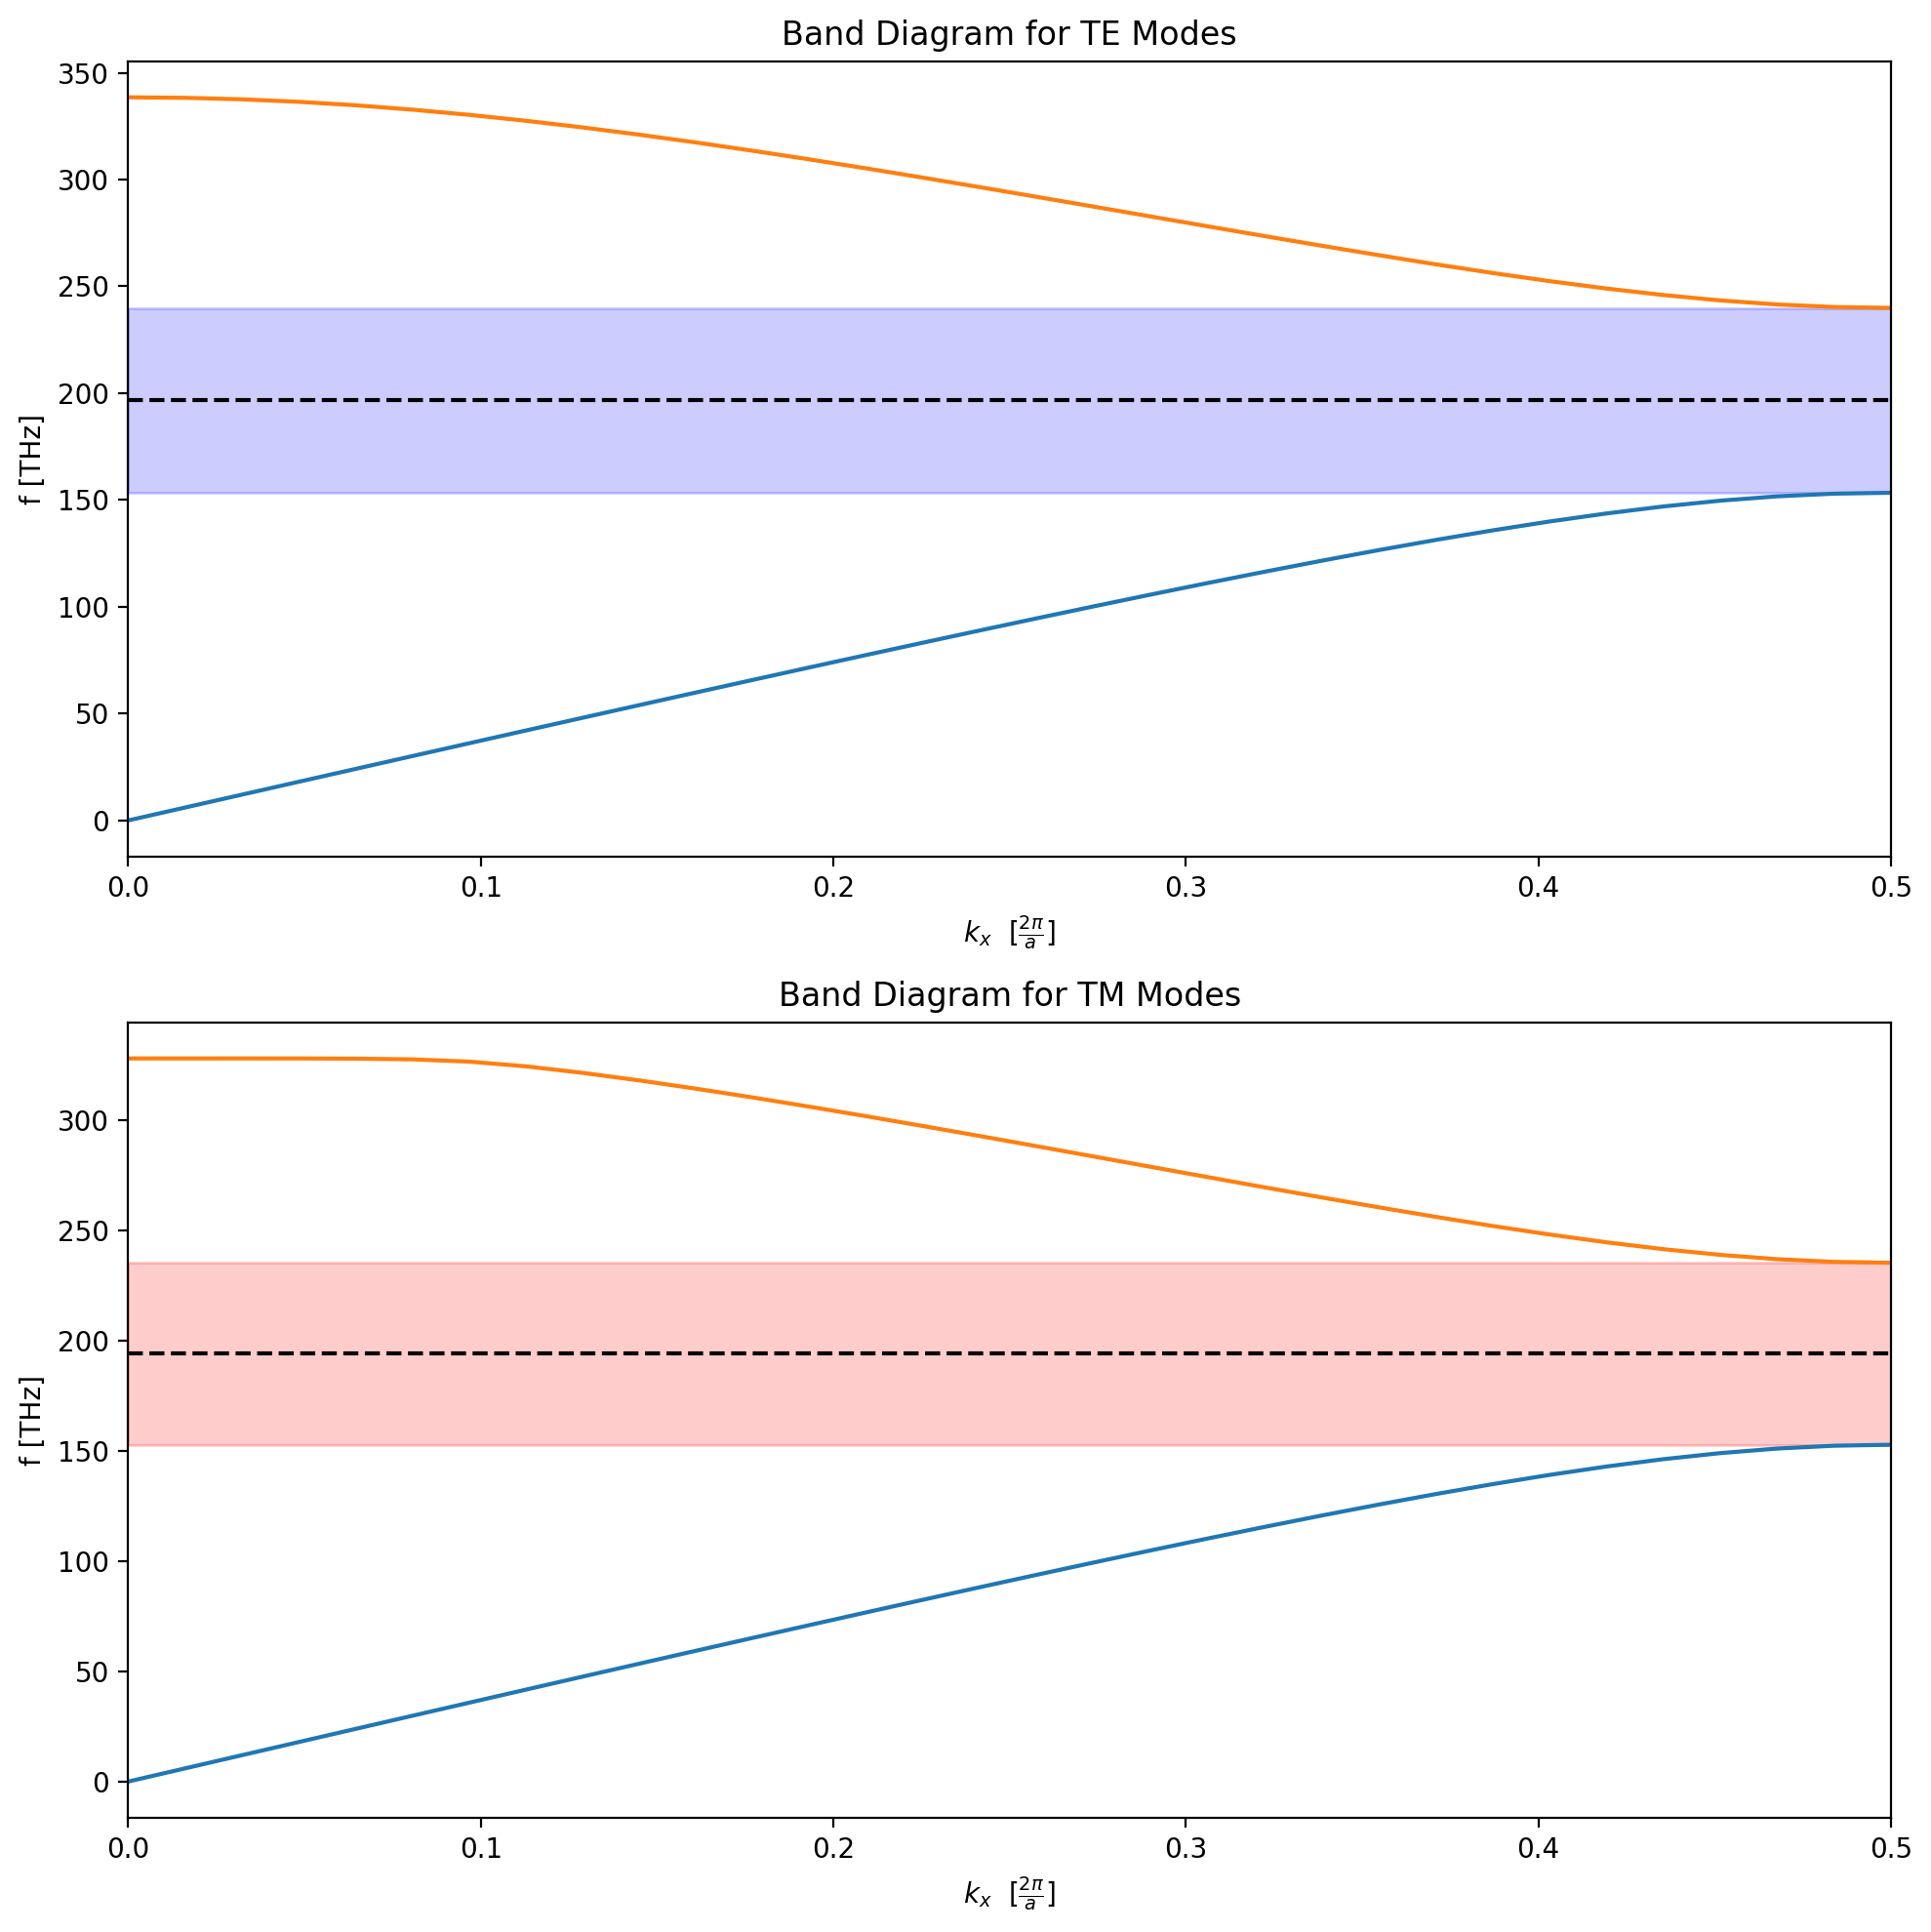

In [115]:
banddiagram_wmpb(width = 500,length = 300, xlength= 150, ylength = 350,  show_geometry= True, band_diagram='max')

In [92]:
#show_geometry = False 
#band_diagram = 'all'
#length = 450
#def objective(x): 
#    width, diameter = x
#    return -banddiagram_wmpb(width, length, diameter, show_geometry=show_geometry, band_diagram=band_diagram)

#difference = 150
#def constraint_difference(x): 
 #   width, diameter = x 
 #   return width - diameter - difference 

#constraints = [
 #   {'type': 'ineq', 'fun': constraint_difference}
#]

#x0 = [540, 390]
#bounds = [(250,length*1.5), (100,length*1.5)]
#res = minimize(
 #   objective,
  #  x0=x0,
  #  bounds = bounds, 
  #  constraints=constraints,
  #  method = 'SLSQP',
  #  options={
  #  'ftol': 1e-4, 
  #  'maxiter':50,
  #  }
#)

In [93]:
#banddiagram_wmpb(width = res.x[0], length = length, diameter = res.x[1], show_geometry=True, band_diagram='max')

In [94]:
#print(res)